# Data Visualisation
### Yuhui Cao

In [4]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = '2'
os.environ['HF_HOME'] = '/eresearch/hie/ycao891/Yuhui/hf_cache'
os.environ['TORCH_HOME'] = '/eresearch/hie/ycao891/Yuhui/torch_cache'

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import tifffile as tiff
import random
import sys
import torch

%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
sys.path.append(str(Path.cwd().parent))

In [6]:
from utils.config import TREATMENT_GROUPS, REGION_GROUPS
TREATMENT_GROUPS, REGION_GROUPS

(['HI', 'HI + HYPO', 'SHAM'],
 ['CA3', 'CA4', 'CA12', 'DG', 'PS1', 'PS2', 'TH1', 'TH2'])

In [9]:
ds_root = Path("../Neuron Dataset")
[x.name for x in ds_root.iterdir() if x.is_dir()]

['HI', 'HI + HYPO', 'SHAM']

Check if dataset is balanced with respect to treatmen and regions

In [10]:
for i, treatment_group in enumerate(TREATMENT_GROUPS):
    print(f"\nTreatment Group: {treatment_group}")
    for j, region in enumerate(REGION_GROUPS):
        temp_path = ds_root / f"{treatment_group}/{region}"

        img_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_img.tif")]
        mask_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_masks.tif")]

        print(f"{region}: Images: {len(img_files)} | Masks: {len(mask_files)}")


Treatment Group: HI
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10

Treatment Group: HI + HYPO
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10

Treatment Group: SHAM
CA3: Images: 10 | Masks: 10
CA4: Images: 10 | Masks: 10
CA12: Images: 10 | Masks: 10
DG: Images: 10 | Masks: 10
PS1: Images: 10 | Masks: 10
PS2: Images: 10 | Masks: 10
TH1: Images: 10 | Masks: 10
TH2: Images: 10 | Masks: 10


In [12]:
test_img = tiff.imread('../Neuron Dataset/HI/CA4/12-067 L CA4 -2_img.tif')
test_img.shape

(1920, 2560, 3)

## Visualise Data
visualise a random sample image from each combination of `treatment_group` and `region`

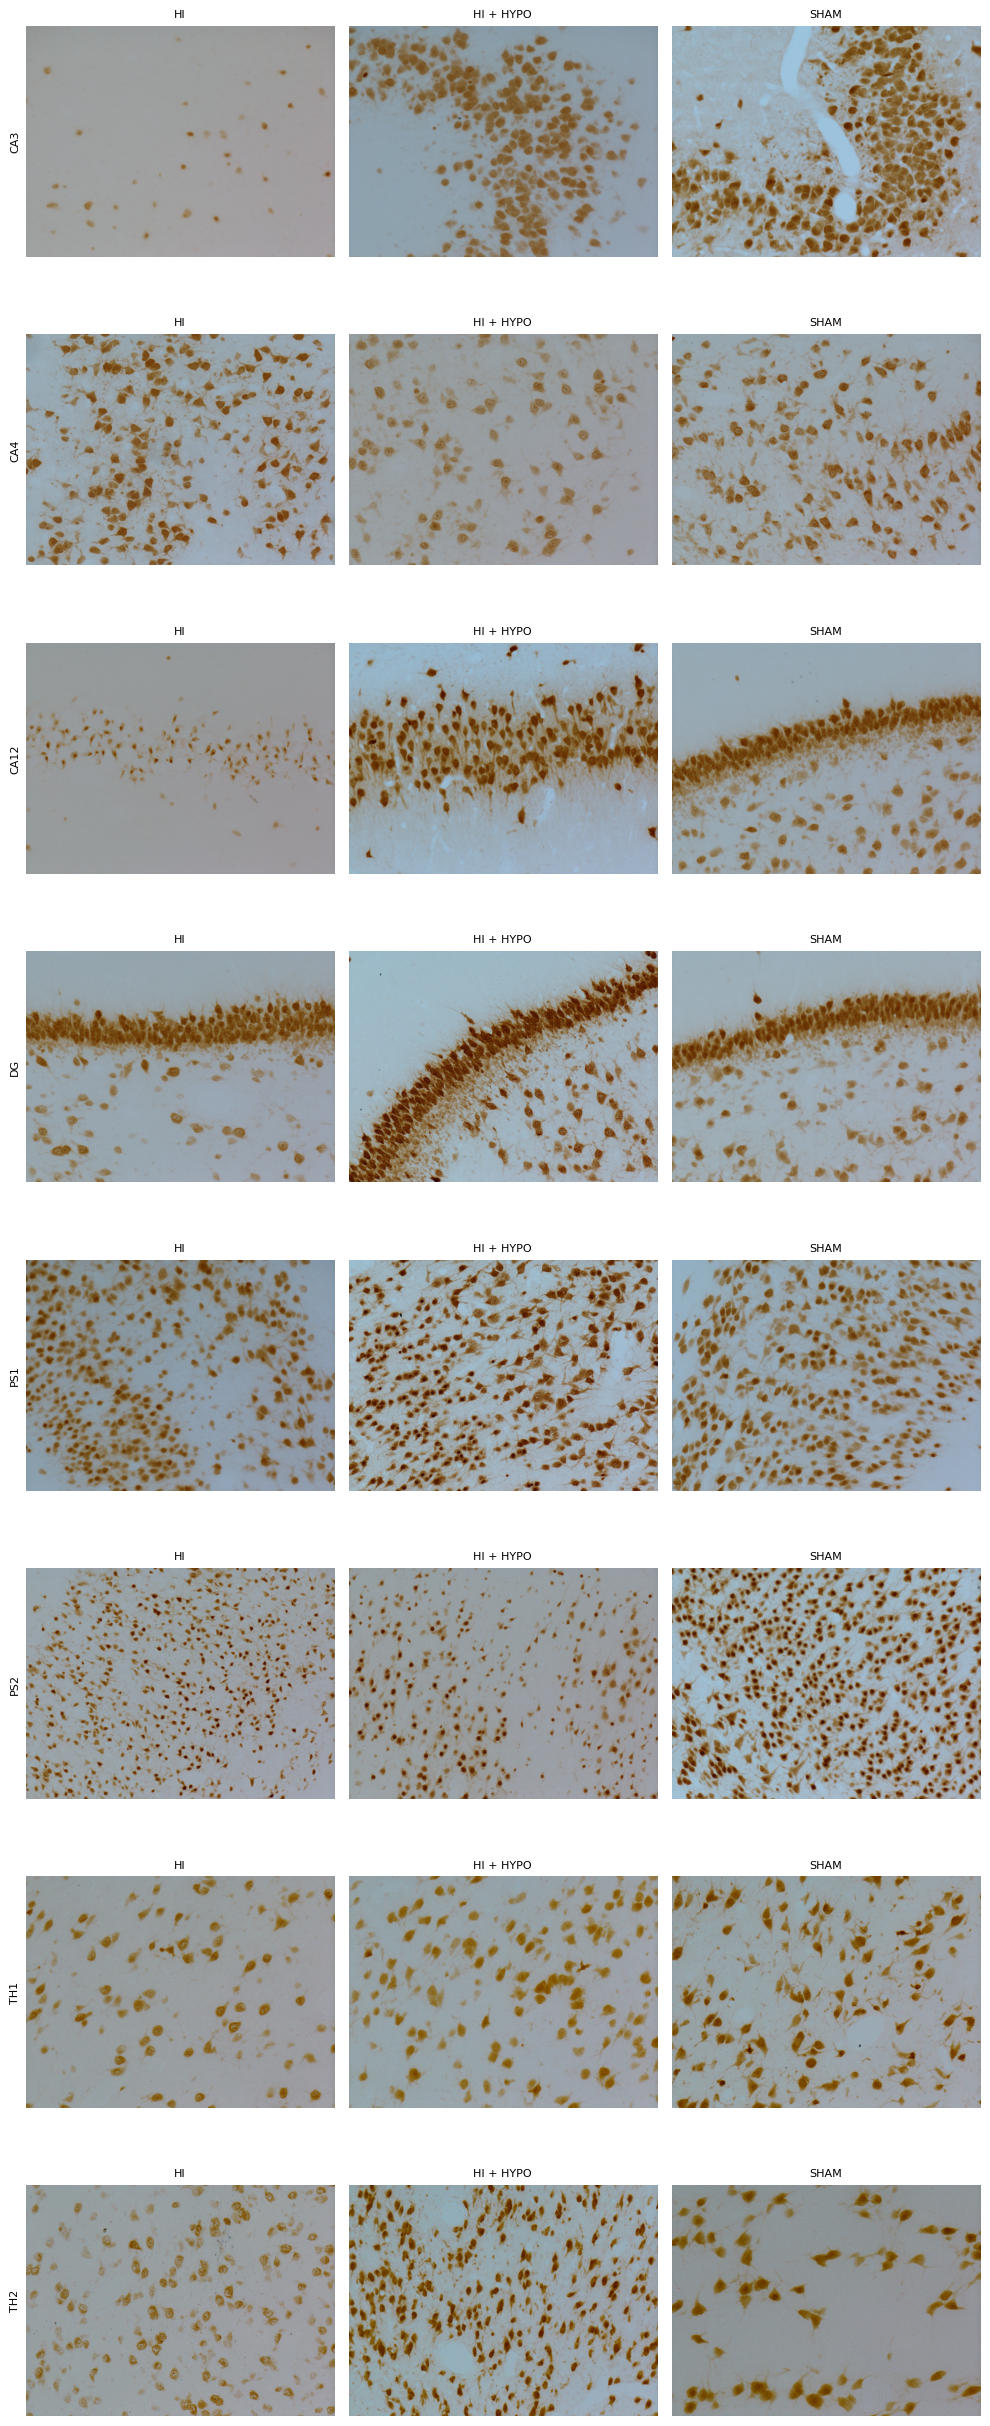

In [13]:
fig, axes = plt.subplots(8, 3, figsize=(10, 25))
for i, region in enumerate(REGION_GROUPS):
    for j, treatment_group in enumerate(TREATMENT_GROUPS):
        temp_path = ds_root / treatment_group / region
        
        # sample a random image
        sample_img = random.choice([x for x in temp_path.iterdir() if x.name.endswith("_img.tif")])
        axes[i, j].imshow(tiff.imread(sample_img, is_ome=False))

        # remove axis values
        axes[i, j].set(xticks=[],yticks=[])

        # treatment group label
        axes[i, j].set_title(treatment_group, fontsize=8)

        # remove black border lines
        for spine in axes[i, j].spines.values():
            spine.set_visible(False)

        # region label
        if j == 0:
            axes[i, j].set_ylabel(region, fontsize=8)

plt.tight_layout()

In [14]:
from data.load_data import load_image_mask_pairs
base_ds = load_image_mask_pairs(ds_root, TREATMENT_GROUPS, REGION_GROUPS)

Loading data from: ../Neuron Dataset/HI/CA3


Loading data from: ../Neuron Dataset/HI/CA4


Loading data from: ../Neuron Dataset/HI/CA12


Loading data from: ../Neuron Dataset/HI/DG


Loading data from: ../Neuron Dataset/HI/PS1


...

Loading data from: ../Neuron Dataset/SHAM/PS1


Loading data from: ../Neuron Dataset/SHAM/PS2


Loading data from: ../Neuron Dataset/SHAM/TH1


Loading data from: ../Neuron Dataset/SHAM/TH2


Loaded 240 image/mask pairs



In [15]:
len(base_ds)

240

In [16]:
sample = base_ds[12]
img, mask, treatment, group = sample.values()

In [17]:
treatment, group

('HI', 'CA4')

In [18]:
img.min(), img.max()

(0, 189)

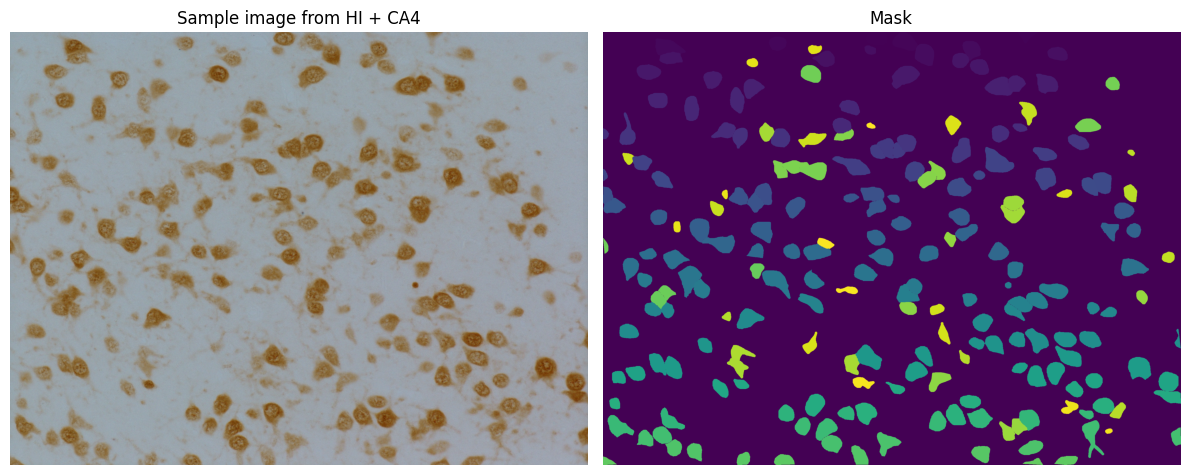

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'Sample image from {treatment} + {group}')

axes[1].imshow(mask)
axes[1].axis('off')
axes[1].set_title('Mask')
plt.tight_layout()

In [20]:
from data.load_data import split_dataset

train_ds, val_ds , test_ds = split_dataset(base_ds, test_size=0.2, val_size=0.1, seed=42)

Train size: 168 | Val size: 24 | Test size: 48


In [21]:
import pandas as pd

def split_distribution_df(splits: dict[str, list[dict]]) -> pd.DataFrame:
    """
    Returns a DataFrame showing image counts per treatment/region/split.
    """
    rows = []
    for split_name, pairs in splits.items():
        for d in pairs:
            rows.append({
                'split':     split_name,
                'treatment': d['treatment'],
                'region':    d['region'],
            })

    df = pd.DataFrame(rows)

    # pivot — rows=treatment+region, columns=split, values=count
    summary = df.groupby(['treatment', 'region', 'split']).size().unstack(fill_value=0)

    # add total column
    summary['total'] = summary.sum(axis=1)

    return summary
summary = split_distribution_df({
    'train': train_ds,
    'val':   val_ds,
    'test':  test_ds
})
print(summary)

split             test  train  val  total
treatment region                         
HI        CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1     10
          TH1        2      7    1     10
          TH2        2      7    1     10
HI + HYPO CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1     10
          TH1        2      7    1     10
          TH2        2      7    1     10
SHAM      CA12       2      7    1     10
          CA3        2      7    1     10
          CA4        2      7    1     10
          DG         2      7    1     10
          PS1        2      7    1     10
          PS2        2      7    1

In [23]:
from data.create_dataset import NeuronDataset
from torch.utils.data import DataLoader
from utils.config import PatchConfig
config = PatchConfig()
train_loader = DataLoader(
    NeuronDataset(train_ds, config=config, train=True, augment=True, aug_prob=1.0), 
    batch_size = 1, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True, 
    persistent_workers=True
)

In [24]:
batch = next(iter(train_loader))
print(len(batch))
test_patch = batch[0]
test_patch.keys()

12


dict_keys(['image', 'neuron_structure', 'treatment_label', 'region_label'])

In [25]:
test_img = test_patch['image'].squeeze(0)
test_img.min(), test_img.max(), test_img.shape

(tensor(-0.8275), tensor(0.3255), torch.Size([3, 256, 256]))

In [26]:
test_mask = test_patch['neuron_structure'].squeeze(0)
test_mask.shape

torch.Size([3, 256, 256])

In [27]:
test_img = (test_img + 1) / 2
test_img = np.transpose(test_img, (1,2,0))

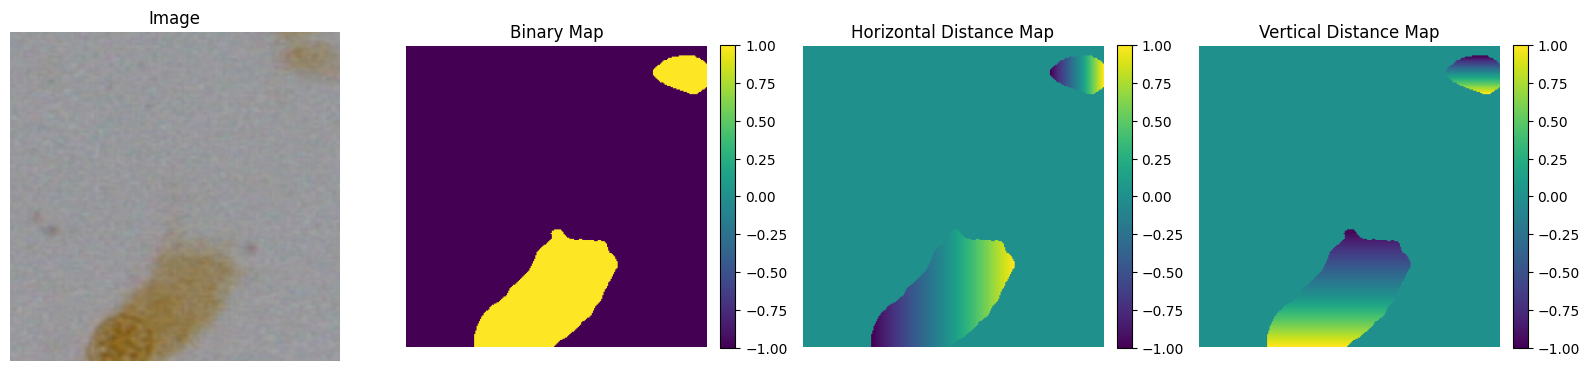

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(16, 12))

axes[0].imshow(test_img)
axes[0].set_title("Image")
axes[0].axis("off")

# Binary map
im1 = axes[1].imshow(test_mask[0])
axes[1].set_title("Binary Map")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Horizontal map
im2 = axes[2].imshow(test_mask[1])
axes[2].set_title("Horizontal Distance Map")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# Vertical map
im3 = axes[3].imshow(test_mask[2])
axes[3].set_title("Vertical Distance Map")
axes[3].axis("off")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [30]:
from model.mask_diffusion import Mask_Diffusion
from utils.config import DiffusionConfig
import torch

config = DiffusionConfig()
diffusion_model = Mask_Diffusion(config=config).to(config.device)
checkpoint = torch.load('../saves/mask_training_2/model_best.pth', map_location=config.device)
diffusion_model.load_state_dict(checkpoint['ema_model'])
diffusion_model.eval()

U-Net parameters: 125,760,451


Mask_Diffusion(
  (model): ConditionedUnet(
    (treatment_emb): Embedding(4, 256)
    (region_emb): Embedding(9, 256)
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): SiLU()
    )
    (cond_proj): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): ResNetBlock(
        (time_mlp): Linear(in_features=256, out_features=128, bias=True)
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (silu): SiLU()
        (residual_proj): Co

In [31]:
TREATMENT_GROUPS, REGION_GROUPS

(['HI', 'HI + HYPO', 'SHAM'],
 ['CA3', 'CA4', 'CA12', 'DG', 'PS1', 'PS2', 'TH1', 'TH2'])

In [107]:
import random
n_samples = 8
# t_labels = random.choices(TREATMENT_GROUPS, k=n_samples)
# r_labels = random.choices(REGION_GROUPS, k=n_samples)
t_labels = ['HI'] * n_samples
r_labels = ['CA3'] * n_samples
print(t_labels, r_labels)

['HI', 'HI', 'HI', 'HI', 'HI', 'HI', 'HI', 'HI'] ['CA3', 'CA3', 'CA3', 'CA3', 'CA3', 'CA3', 'CA3', 'CA3']


In [108]:
from utils.config import TREATMENT_MAP, REGION_MAP

treatment_labels = torch.tensor([TREATMENT_MAP[t] for t in t_labels]).to(config.device)
region_labels = torch.tensor([REGION_MAP[r] for r in r_labels]).to(config.device)

treatment_labels, region_labels

(tensor([0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0'),
 tensor([0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0'))

In [117]:
samples = diffusion_model.sample(n_samples, treatment_labels, region_labels, steps=100, guidance_scale=3.0).to(config.device)

In [118]:
sample_input = samples.clone()
sample_input.shape

torch.Size([8, 3, 256, 256])

In [119]:
samples = samples.cpu().numpy()

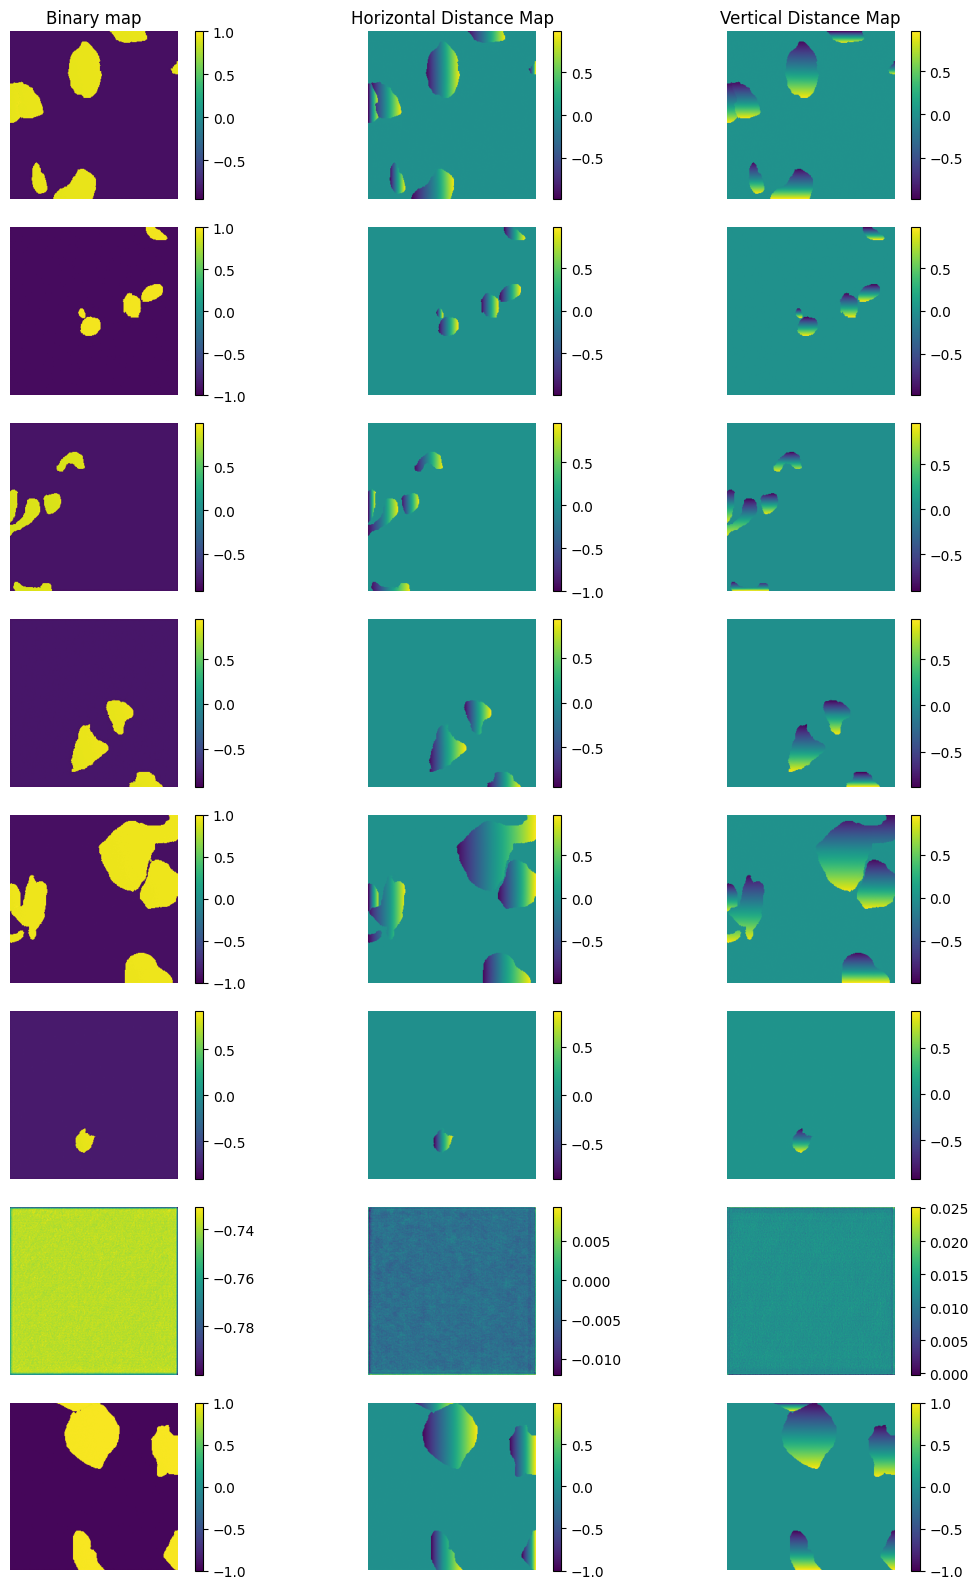

In [120]:
fig, axes = plt.subplots(8, 3, figsize=(12, 16))

titles = [
    'Binary map',
    'Horizontal Distance Map',
    'Vertical Distance Map'
]

for i in range(8):
    for j in range(3):
        im = axes[i, j].imshow(samples[i, j])
        axes[i, j].axis('off')
        
        if i == 0:
            axes[i, j].set_title(titles[j])

        fig.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

    axes[i, 0].set_ylabel(f'Batch {i+1}', fontsize=12)

plt.tight_layout()
plt.show()